# Predictive Maintenance - Machine Temperature Anomaly Detection

## Objective
Detect abnormal machine behavior using time-series temperature data.

## Step 1
Load dataset and visualize temperature trend.

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

#Load dataset directly from Github
url = "https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv"
df = pd.read_csv(url)
df.head()

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  datetime64[ns]
 1   value      22695 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 354.7 KB


,timestamp,value
count,22695,22695.000000
mean,2014-01-11 06:16:49.887640576,85.926498
min,2013-12-02 21:15:00,2.084721
25%,2013-12-22 14:02:30,83.080078
50%,2014-01-11 05:50:00,89.408246
75%,2014-01-30 22:37:30,94.016252
max,2014-02-19 15:25:00,108.510543
std,NaN,13.746912


In [ ]:
# Convert timestamp to datetime

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
# Checking datatypes after changing the datatype
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  datetime64[ns]
 1   value      22695 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 354.7 KB


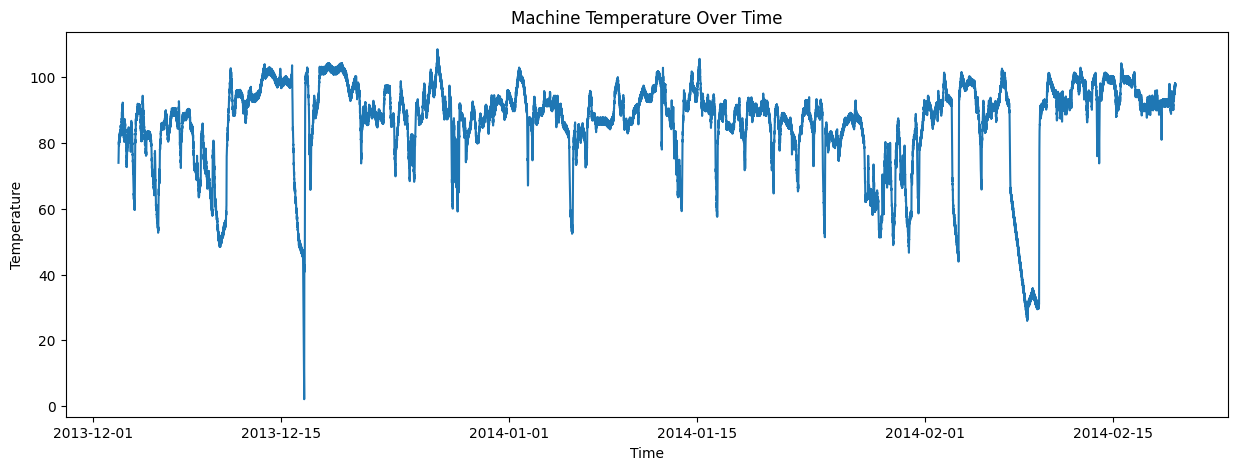

In [ ]:
#Visualizing data
plt.figure(figsize=(15,5))
plt.plot(df['timestamp'],df['value'])
plt.title('Machine Temperature Over Time')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

In [ ]:
# setting timestamp as index
df.set_index('timestamp',inplace=True)
df.head()

,value
timestamp,
2013-12-02 21:15:00,73.967322
2013-12-02 21:20:00,74.935882
2013-12-02 21:25:00,76.124162
2013-12-02 21:30:00,78.140707
2013-12-02 21:35:00,79.329836


In [ ]:
# Basic statistics
mean = df['value'].mean()
std = df['value'].std()

print(f"Mean temperature:{mean:.2f}")
print(f"Standard Deviation:{std:.2f}")

<class 'numpy.float64'> <class 'float'>
Mean temperature:85.93
Standard Deviation:13.75


## Adding Rolling mean

After overlaying Rolling mean on the original Temperature. We are seperating two things.
1. Short Time Fluctation(noise): The Original Temperature Line
2. Underlying trend: The rolling mean line

In [3]:
# Adding Rolling mean
df['rolling_mean'] = df['value'].rolling(window=50).mean()

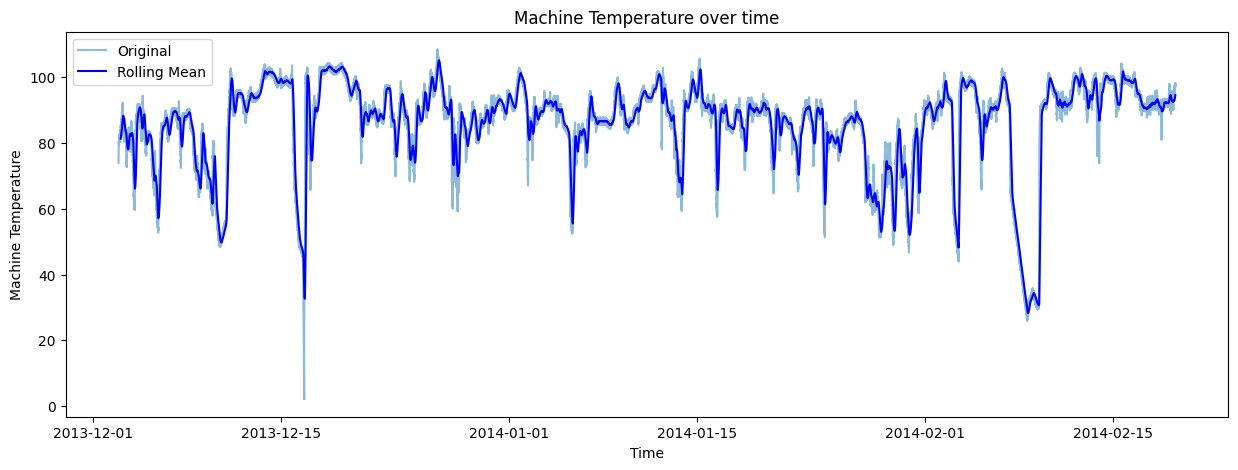

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],alpha=0.5,label='Original')
plt.plot(df.index,df['rolling_mean'],label='Rolling Mean',color = 'b')
plt.legend()
plt.title('Machine Temperature over time')
plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.show()

## Observation
During **normal operation** temperature shows random flactuation around a stable baseline.

**Event/Failure behaviour:** The system shows gradual shift in machine temperature , indicating abnormal machine behaviour.

## Statistical Threshold method
we use the 3 sigma rule to detect anomalies in machine temperature
Any value outside mean + 3 standard deviation value is marked as an anamoly.



In [4]:
# Calcaluating upper and lower limit
mean_temp = df['value'].mean()
std_temp = df['value'].std()

upper_limit = mean_temp + 3 * std_temp
lower_limit = mean_temp - 3 * std_temp

upper_limit,lower_limit

(np.float64(127.16723562995054), np.float64(44.68576079140987))

In [5]:
# Adding limit columns to dataframe
df['upper_limit'] = upper_limit
df['lower_limit'] = lower_limit

In [6]:
# Detect anomalies

df['anomaly'] = ((df['value'] > df['upper_limit']) | (df['value']<df['lower_limit']))

In [7]:
# Extract only anomalies
anomalies = df[df['anomaly']==True]
anomalies.head()

,timestamp,value,rolling_mean,upper_limit,lower_limit,anomaly
3962,2013-12-16 15:25:00,43.177455,46.859075,127.167236,44.685761,True
3963,2013-12-16 15:30:00,41.308989,46.743834,127.167236,44.685761,True
3964,2013-12-16 15:35:00,40.461427,46.603406,127.167236,44.685761,True
3965,2013-12-16 15:40:00,37.791275,46.416193,127.167236,44.685761,True
3966,2013-12-16 15:45:00,36.249653,46.181740,127.167236,44.685761,True


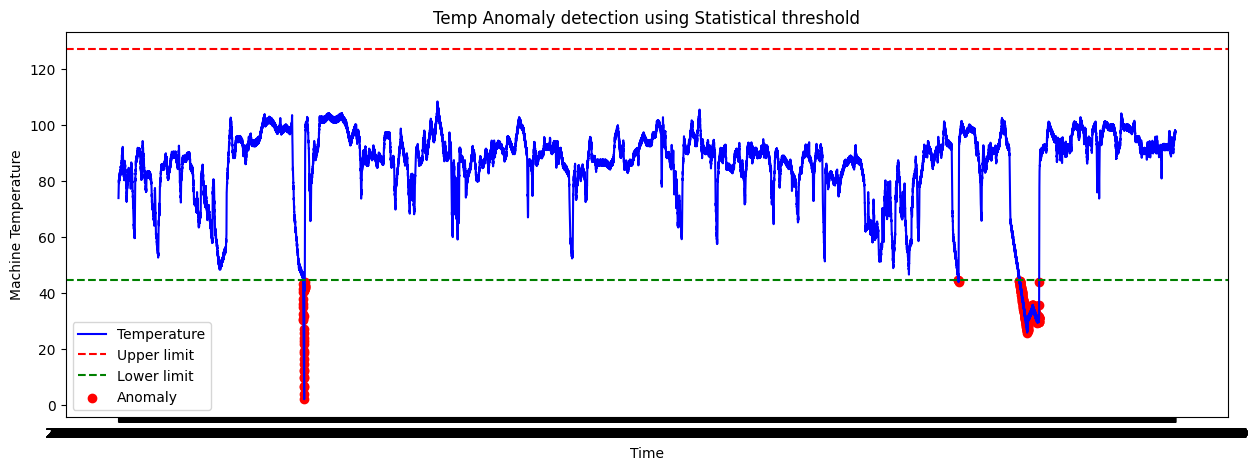

In [ ]:
#Visualize the treshold
plt.figure(figsize=(15,5))
plt.plot(df.index,df['value'],color='b',label='Temperature')

plt.axhline(upper_limit,color='r',linestyle = '--',label='Upper limit')
plt.axhline(lower_limit,color='g',linestyle = '--',label='Lower limit')
plt.scatter(anomalies.index,anomalies['value'],color='r',label='Anomaly')

plt.xlabel('Time')
plt.ylabel('Machine Temperature')
plt.legend()
plt.title('Temp Anomaly detection using Statistical threshold')
plt.show()

## Calculate rolling mean and standard deviation

In [8]:
window = 50
rolling_mean = df['value'].rolling(window=window).mean()
rolling_std = df['value'].rolling(window=window).std()

## Creating rolling threshold

In [10]:
df['upper_limit_rolling'] = rolling_mean + 3*rolling_std
df['lower_limit_rolling'] = rolling_mean - 3*rolling_std

## Detecting rolling anomalies

In [13]:
df['anomal_rolling'] = (df['value']>df['upper_limit_rolling'])|(df['value']<df['upper_limit_rolling'])

## Extracting Anomalies

In [18]:
anomal_rolling = df[df['anomal_rolling']==True]
anomal_rolling.head()

,timestamp,value,rolling_mean,upper_limit,lower_limit,anomaly,upper_limit_rolling,lower_limit_rolling,anomal_rolling
49,2013-12-03 01:20:00,85.344624,81.307319,127.167236,44.685761,False,88.094666,74.519972,True
50,2013-12-03 01:25:00,84.671962,81.521412,127.167236,44.685761,False,87.672100,75.370724,True
51,2013-12-03 01:30:00,85.302762,81.728749,127.167236,44.685761,False,87.394142,76.063357,True
52,2013-12-03 01:35:00,84.349211,81.893250,127.167236,44.685761,False,87.122014,76.664487,True
53,2013-12-03 01:40:00,84.555844,82.021553,127.167236,44.685761,False,87.111201,76.931906,True


## Plot Rolling Detection

In [27]:
df_zoom = df.iloc[3000:5000]
anomal_rolling_zoom = anomal_rolling.iloc[30000:50000]

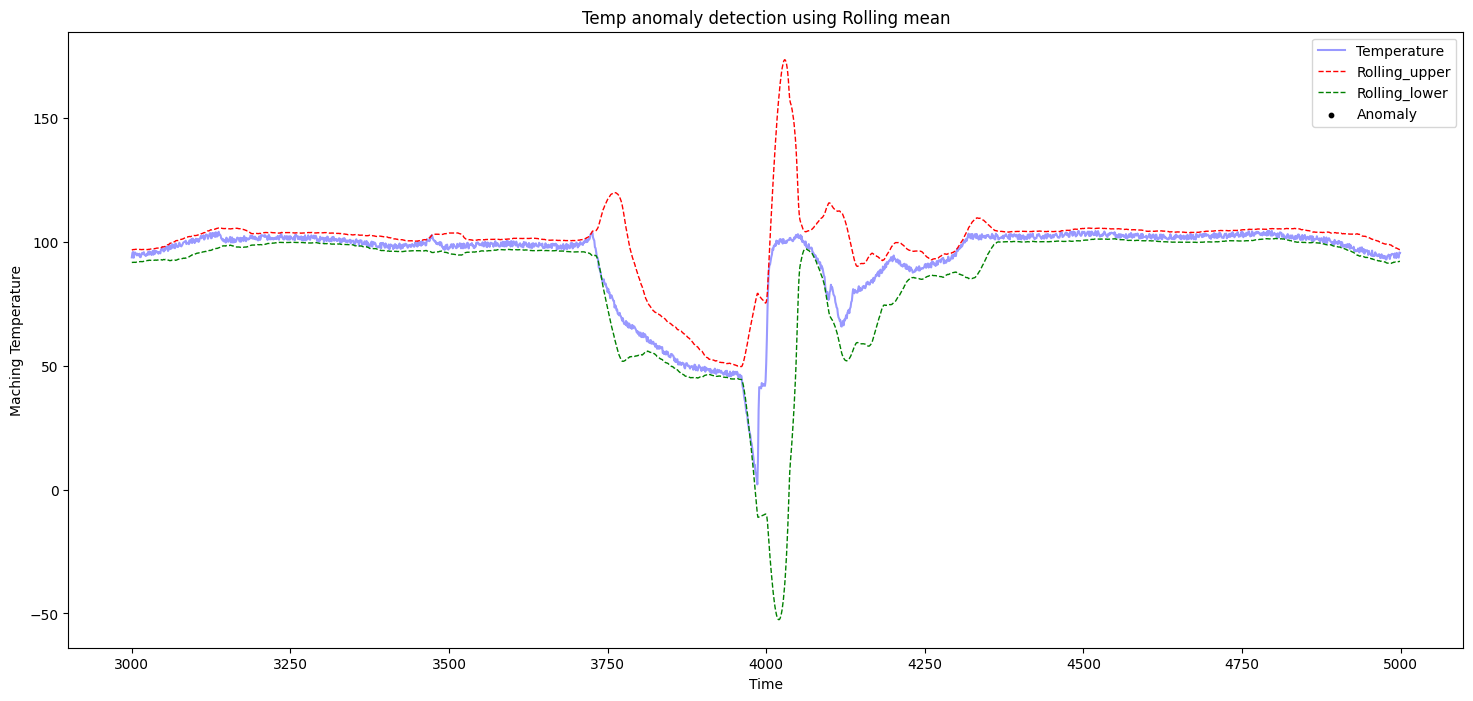

In [28]:
plt.figure(figsize=(18,8))
plt.plot(df_zoom.index,df_zoom['value'],color='b',alpha=0.4,label='Temperature')

plt.plot(df_zoom.index,df_zoom['upper_limit_rolling'],color='red',linewidth=1,linestyle = '--',label='Rolling_upper')
plt.plot(df_zoom.index,df_zoom['lower_limit_rolling'],color='green',linewidth=1,linestyle='--',label='Rolling_lower')

plt.scatter(anomal_rolling_zoom.index,anomal_rolling_zoom['value'],s=10,color='black',label='Anomaly')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Maching Temperature')
plt.title('Temp anomaly detection using Rolling mean')
plt.show()